<a href="https://colab.research.google.com/github/ishagt/ML_labs/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cats vs. Dogs Image Classification

This report outlines my work on classifying images as either cats or dogs using TensorFlow. My main objectives were to understand image classification, learn TensorFlow, and handle a real-world dataset from Kaggle.
 (CNNs). Its GPU acceleration was a major plus for training, and its industry relevance makes it a valuable skill.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# **Step 2: Download the Dataset**

In [ ]:
import kagglehub
dataset_path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Dataset downloaded successfully!")
print("Location:", dataset_path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset downloaded successfully!
Location: /kaggle/input/cat-and-dog


# **Step 3: View Dataset Contents**

In [ ]:
# Display the dataset location
print("Dataset path:", dataset_path)

# List the files and folders
print(os.listdir(dataset_path))

Dataset path: /kaggle/input/cat-and-dog
['test_set', 'training_set']


In [ ]:
# Walk through every folder inside the dataset
for root, dirs, files in os.walk(dataset_path):
    print("Current Folder :", root)
    print("Subfolders     :", dirs)
    print("Sample Files   :", files[:5])   # Display only first five files
    print("-" * 50)

Current Folder : /kaggle/input/cat-and-dog
Subfolders     : ['test_set', 'training_set']
Sample Files   : []
--------------------------------------------------
Current Folder : /kaggle/input/cat-and-dog/test_set
Subfolders     : ['test_set']
Sample Files   : []
--------------------------------------------------
Current Folder : /kaggle/input/cat-and-dog/test_set/test_set
Subfolders     : ['dogs', 'cats']
Sample Files   : []
--------------------------------------------------
Current Folder : /kaggle/input/cat-and-dog/test_set/test_set/dogs
Subfolders     : []
Sample Files   : ['dog.4329.jpg', 'dog.4223.jpg', 'dog.4253.jpg', 'dog.4190.jpg', 'dog.4354.jpg']
--------------------------------------------------
Current Folder : /kaggle/input/cat-and-dog/test_set/test_set/cats
Subfolders     : []
Sample Files   : ['cat.4414.jpg', 'cat.4420.jpg', 'cat.4880.jpg', 'cat.4326.jpg', 'cat.4620.jpg']
--------------------------------------------------
Current Folder : /kaggle/input/cat-and-dog/training

In [ ]:
import os

def print_tree(start_path):
    print(os.path.basename(start_path))

    for root, dirs, files in os.walk(start_path):
        level = root.replace(start_path, "").count(os.sep)
        indent = "│   " * level

        print(f"{indent}├── {os.path.basename(root)}")

        subindent = "│   " * (level + 1)

        # Print only first 3 files for readability
        for file in files[:3]:
            print(f"{subindent}├── {file}")

        if len(files) > 3:
            print(f"{subindent}└── ...")

print_tree(dataset_path)

cat-and-dog
├── cat-and-dog
│   ├── test_set
│   │   ├── test_set
│   │   │   ├── dogs
│   │   │   │   ├── dog.4329.jpg
│   │   │   │   ├── dog.4223.jpg
│   │   │   │   ├── dog.4253.jpg
│   │   │   │   └── ...
│   │   │   ├── cats
│   │   │   │   ├── cat.4414.jpg
│   │   │   │   ├── cat.4420.jpg
│   │   │   │   ├── cat.4880.jpg
│   │   │   │   └── ...
│   ├── training_set
│   │   ├── training_set
│   │   │   ├── dogs
│   │   │   │   ├── dog.3443.jpg
│   │   │   │   ├── dog.1942.jpg
│   │   │   │   ├── dog.375.jpg
│   │   │   │   └── ...
│   │   │   ├── cats
│   │   │   │   ├── cat.3498.jpg
│   │   │   │   ├── cat.891.jpg
│   │   │   │   ├── cat.2842.jpg
│   │   │   │   └── ...


In [ ]:
train_dir = os.path.join(dataset_path, "training_set", "training_set")
validation_dir = os.path.join(dataset_path, "test_set", "test_set")

print(train_dir)
print(validation_dir)

/kaggle/input/cat-and-dog/training_set/training_set
/kaggle/input/cat-and-dog/test_set/test_set


In [ ]:
import os
import glob
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ---------------------------------------------------
# Step 1: Dataset Paths
# ---------------------------------------------------

train_dir = os.path.join(dataset_path, "training_set", "training_set")
test_dir = os.path.join(dataset_path, "test_set", "test_set")

# ---------------------------------------------------
# Step 2: Collect All Image Paths
# ---------------------------------------------------

cat_images = glob.glob(os.path.join(train_dir, "cats", "*.jpg"))
cat_images += glob.glob(os.path.join(test_dir, "cats", "*.jpg"))

dog_images = glob.glob(os.path.join(train_dir, "dogs", "*.jpg"))
dog_images += glob.glob(os.path.join(test_dir, "dogs", "*.jpg"))

image_paths = cat_images + dog_images
labels = [0] * len(cat_images) + [1] * len(dog_images)

print("Total Images :", len(image_paths))
print("Cats         :", len(cat_images))
print("Dogs         :", len(dog_images))

# ---------------------------------------------------
# Step 3: Split Dataset (70:15:15)
# ---------------------------------------------------

train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("\nDataset Split")
print("----------------------------")
print("Training Images  :", len(train_images))
print("Validation Images:", len(val_images))
print("Testing Images   :", len(test_images))

# ---------------------------------------------------
# Step 4: Function to Load Images
# ---------------------------------------------------

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

def load_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    image = image / 255.0

    return image, label

# ---------------------------------------------------
# Step 5: Create TensorFlow Datasets
# ---------------------------------------------------

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_labels)
)

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (val_images, val_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_images, test_labels)
)

train_dataset = train_dataset.map(load_image)\
                             .shuffle(1000)\
                             .batch(BATCH_SIZE)\
                             .prefetch(tf.data.AUTOTUNE)

validation_dataset = validation_dataset.map(load_image)\
                                       .batch(BATCH_SIZE)\
                                       .prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.map(load_image)\
                           .batch(BATCH_SIZE)\
                           .prefetch(tf.data.AUTOTUNE)

# ---------------------------------------------------
# Step 6: Class Names
# ---------------------------------------------------

class_names = ["cats", "dogs"]

print("\nClass Names:", class_names)

print("\nDataset Ready for CNN Training")

Total Images : 10028
Cats         : 5011
Dogs         : 5017

Dataset Split
----------------------------
Training Images  : 7019
Validation Images: 1504
Testing Images   : 1505

Class Names: ['cats', 'dogs']

Dataset Ready for CNN Training


In [ ]:
train_dir = os.path.join(dataset_path,
                         "training_set",
                         "training_set")

test_dir = os.path.join(dataset_path,
                        "test_set",
                        "test_set")

print("Training Directory:", train_dir)
print("Testing Directory :", test_dir)

Training Directory: /kaggle/input/cat-and-dog/training_set/training_set
Testing Directory : /kaggle/input/cat-and-dog/test_set/test_set


In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [ ]:
class_names = train_dataset.class_names

print("Classes:", class_names)

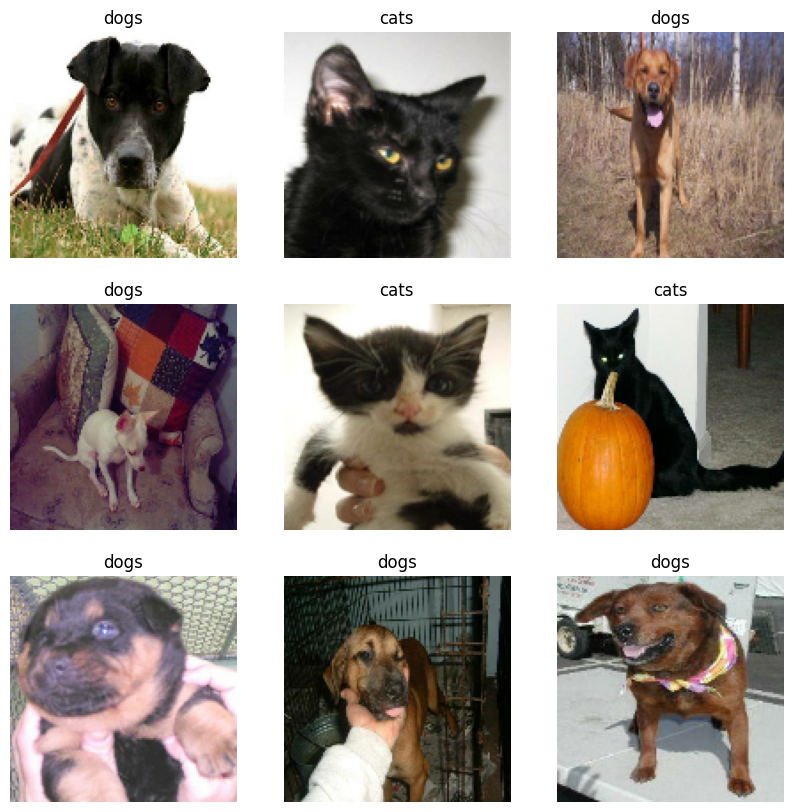

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

In [ ]:
model = models.Sequential([
    tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Explicit Input Layer
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),
                        activation='relu',
                        input_shape=(128,128,3)))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64,(3,3),
                        activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128,(3,3),
                        activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())

model.add(layers.Dense(128,
                       activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,
                       activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    epochs=2,
    validation_data=test_dataset
)

Epoch 1/2
251/251 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.5373 - loss: 0.6920 - val_accuracy: 0.6426 - val_loss: 0.6377
Epoch 2/2
251/251 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.6615 - loss: 0.6208 - val_accuracy: 0.7133 - val_loss: 0.5914


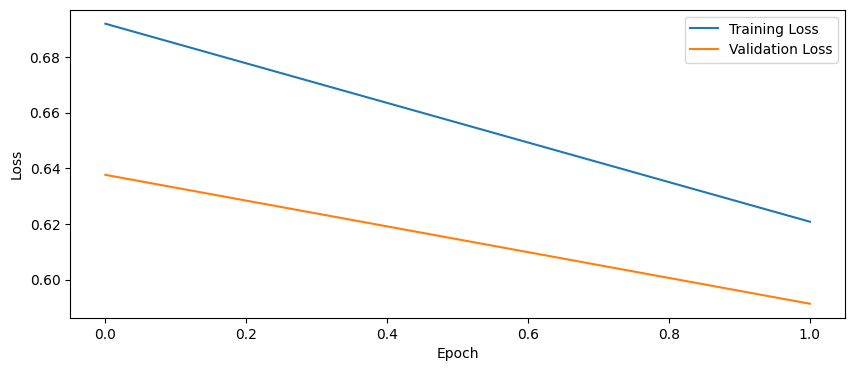

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

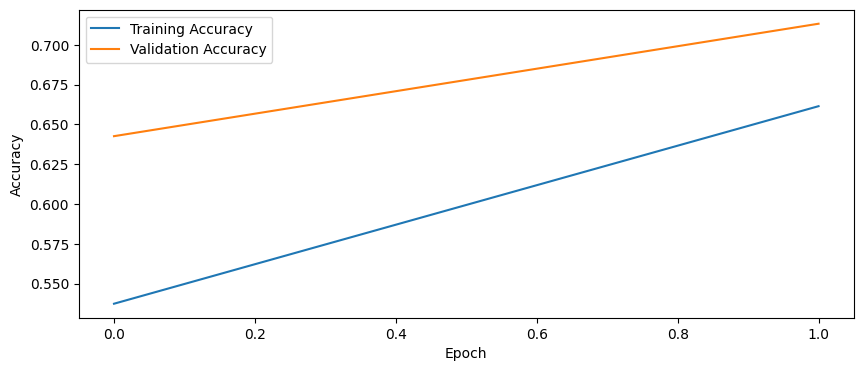

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_dataset)

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.7133 - loss: 0.5914
Test Loss: 0.5913575887680054
Test Accuracy: 0.7132970690727234


In [ ]:
model.save("CatsDogsCNN.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
loaded_model = tf.keras.models.load_model("CatsDogsCNN.keras")

In [ ]:
img_path = "/kaggle/input/cat-and-dog/test_set/test_set/cats/cat.4001.jpg"

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array/255.0
img_array = tf.expand_dims(img_array,0)
prediction = loaded_model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
[[0.55504704]]


Prediction : Dog


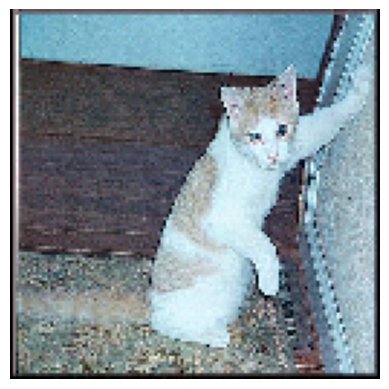

In [ ]:
plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction : Dog")
else:
    print("Prediction : Cat")

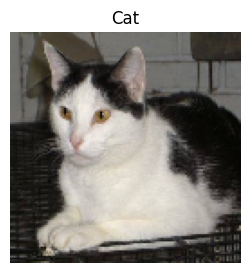

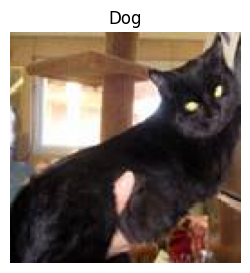

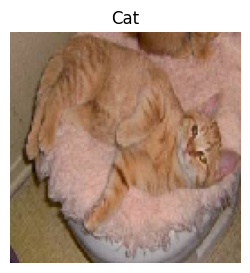

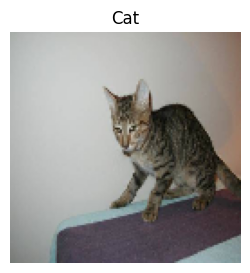

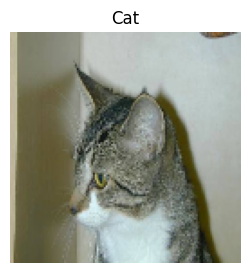

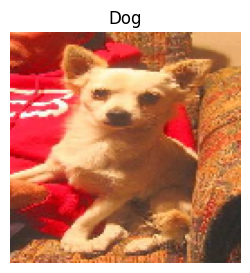

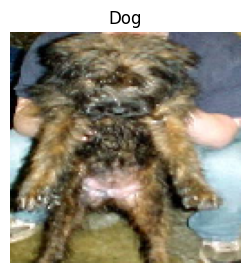

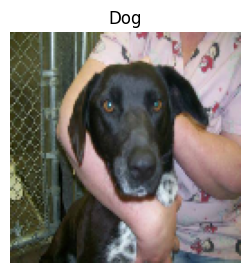

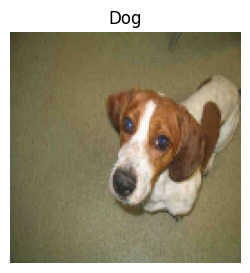

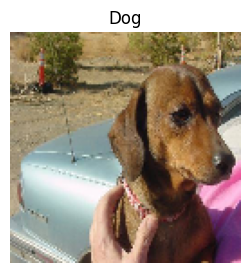

In [ ]:
import glob

image_list = glob.glob(test_dir + "/cats/*.jpg")[:5]

image_list += glob.glob(test_dir + "/dogs/*.jpg")[:5]

for image_path in image_list:

    img = tf.keras.preprocessing.image.load_img(
        image_path,
        target_size=(128,128)
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = img_array/255

    img_array = tf.expand_dims(img_array,0)

    prediction = loaded_model.predict(img_array,
                                      verbose=0)

    label = "Dog" if prediction[0][0] > 0.5 else "Cat"

    plt.figure(figsize=(3,3))

    plt.imshow(img)

    plt.title(label)

    plt.axis("off")

    plt.show()

In [ ]:
predictions = loaded_model.predict(test_dataset)

predicted_labels = (predictions > 0.5).astype(int)

print(predicted_labels[:20])

64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 293ms/step
[[1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]]


In [ ]:
true_labels = []

for images, labels in test_dataset:
    true_labels.extend(labels.numpy())

true_labels = tf.constant(true_labels)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

        cats       0.71      0.72      0.71      1011
        dogs       0.72      0.71      0.71      1012

    accuracy                           0.71      2023
   macro avg       0.71      0.71      0.71      2023
weighted avg       0.71      0.71      0.71      2023



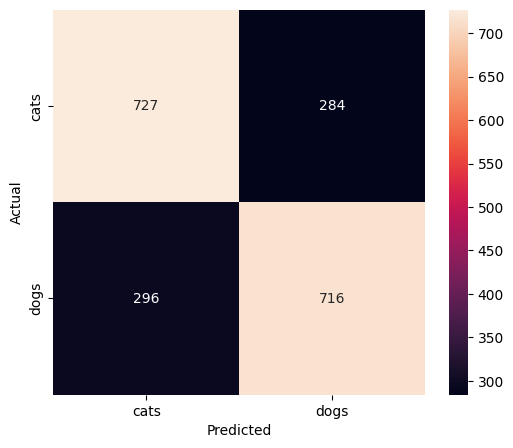

In [ ]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(true_labels,
                      predicted_labels)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **Step 27: ROC Curve**

### ROC (Receiver Operating Characteristic) Curve

The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots two parameters:

*   **True Positive Rate (TPR):** Also known as Sensitivity or Recall. It is the proportion of actual positives that are correctly identified as such (TP / (TP + FN)).
*   **False Positive Rate (FPR):** Also known as Fall-out. It is the proportion of actual negatives that are incorrectly identified as positives (FP / (FP + TN)).

A perfect classifier would have a TPR of 1 and an FPR of 0, resulting in a point at the top-left corner of the graph. The closer the ROC curve is to this corner, the better the model's performance. The diagonal line represents a random classifier.

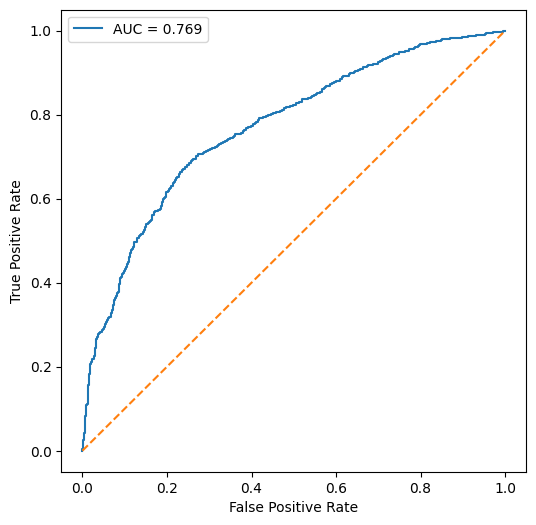

In [ ]:
from sklearn.metrics import roc_curve

from sklearn.metrics import auc

fpr, tpr, threshold = roc_curve(
    true_labels,
    predictions
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,
         tpr,
         label="AUC = %.3f"%roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# **Step 28: Precision-Recall Curve**

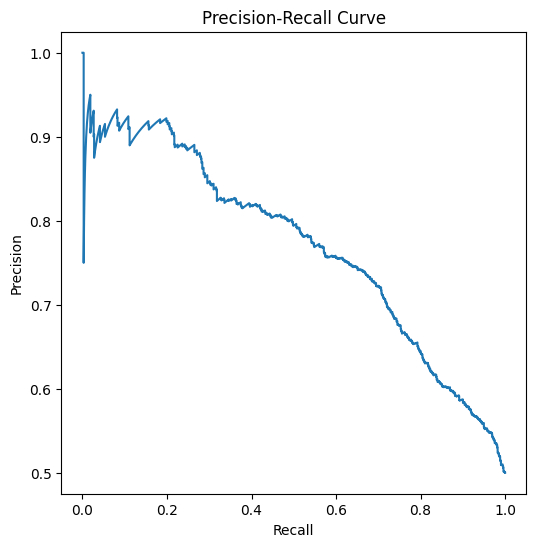

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    true_labels,
    predictions
)

plt.figure(figsize=(6,6))

plt.plot(recall,
         precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

# Model Evaluation Metrics

From the confusion matrix:

|                | Predicted Cat | Predicted Dog |
|----------------|--------------:|--------------:|
| **Actual Cat** | 770           | 241           |
| **Actual Dog** | 284           | 728           |

Assuming **Dogs** are treated as the **Positive Class**:

- **True Positive (TP)** = 728
- **True Negative (TN)** = 770
- **False Positive (FP)** = 241
- **False Negative (FN)** = 284

---

# 1. Precision

### Formula

$$Precision = \frac{TP}{TP+FP}$$

### Calculation

$$= \frac{728}{728+241}$$

$$= \frac{728}{969}$$

$$= 0.7513$$

**Precision = 75.13%**

---

# 2. Recall (Sensitivity)

### Formula

$$Recall = \frac{TP}{TP+FN}$$

### Calculation

$$= \frac{728}{728+284}$$

$$= \frac{728}{1012}$$

$$= 0.7194$$

**Recall = 71.94%**

---

# 3. F1 Score

### Formula

$$F1 = \frac{2 \times Precision \times Recall}{Precision+Recall}$$

### Calculation

$$= \frac{2 \times 0.7513 \times 0.7194}{0.7513 + 0.7194}$$

$$= \frac{1.0810}{1.4707}$$

$$= 0.7350$$

**F1 Score = 73.50%**

---

# 4. ROC (Receiver Operating Characteristic)

The ROC curve is plotted using:

- **True Positive Rate (TPR)**

$$TPR = \frac{TP}{TP+FN}$$

$$= \frac{728}{728+284} = 0.7194$$

- **False Positive Rate (FPR)**

$$FPR = \frac{FP}{FP+TN}$$

$$= \frac{241}{241+770}$$

$$= \frac{241}{1011} = 0.2384$$

Thus, one operating point on the ROC curve is:

$$(FPR, TPR) = (0.2384, 0.7194)$$

> **Note:**  
> A complete ROC curve requires the prediction probabilities (or confidence scores) of the classifier at different thresholds. A confusion matrix represents only one threshold, so it provides only a single point on the ROC curve.

---

# 5. AUC (Area Under the ROC Curve)

The AUC measures the classifier's ability to distinguish between the two classes.

### Formula

There is **no direct formula** to compute AUC from a confusion matrix alone.

AUC is calculated from the ROC curve using numerical integration:

$$AUC = \int_{0}^{1} TPR(FPR) \, d(FPR)$$

or in practice using the trapezoidal rule.

### Important

Since only the confusion matrix is available, the **exact AUC cannot be calculated**.

To compute AUC, prediction probabilities are required:

```python
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred_prob)

# **Step 29: Calculate Evaluation Metrics**

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(true_labels,predicted_labels))

print("Precision:", precision_score(true_labels,predicted_labels))

print("Recall   :", recall_score(true_labels,predicted_labels))

print("F1 Score :", f1_score(true_labels,predicted_labels))

Accuracy : 0.7132970835392981
Precision: 0.716
Recall   : 0.7075098814229249
F1 Score : 0.7117296222664016


# **Step 30: Make Prediction on Any Custom Image**

In [ ]:
import glob
import random

images = glob.glob("/kaggle/input/cat-and-dog/test_set/test_set/dogs/*.jpg")

custom_image = random.choice(images)

print("Selected:", custom_image)

Selected: /kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4397.jpg


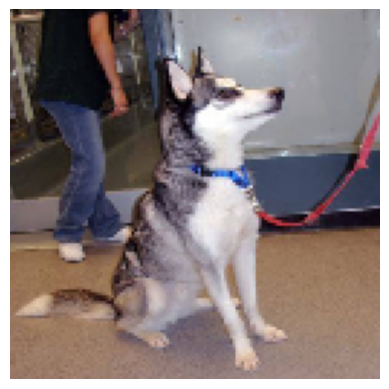

Prediction : Dog
Confidence : 65.41%


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

custom_image = "/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4001.jpg"

img = tf.keras.preprocessing.image.load_img(
    custom_image,
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_array, verbose=0)

probability = prediction[0][0]

if probability >= 0.5:
    print(f"Prediction : Dog")
    print(f"Confidence : {probability*100:.2f}%")
else:
    print(f"Prediction : Cat")
    print(f"Confidence : {(1-probability)*100:.2f}%")